# College Scorecard — College Finder Pipeline

**The question:** Where do low-income (Pell) students actually graduate — across both community colleges and four-year schools — so counselors can steer students toward places they'll finish and afford? *(Built for Student Leadership Network.)*

---

### How to use this notebook
- **Run top to bottom.** Each section has a *What this does* note and a **🔑 Key idea** (the transferable concept).
- **✏️ Try this** boxes are optional practice.
- **Copy tip:** wrap output in `print(...)` so it pastes cleanly.

### Project map
✅ First call · ✅ Pull (incl. community colleges) · ✅ Clean & merge · ✅ Compare 2-year vs 4-year · ✅ Export to the tool · ⬜ Wire data into the explorer · ⬜ Writeup

## 1 · Setup — load your API key

**What this does:** pulls your free data.gov key out of Colab's **Secrets** (🔑 icon, left sidebar) so it never gets typed into the notebook.

🔑 **Key idea:** the key is a **library card** — it identifies you and tracks usage (1,000 requests/hour). Never paste it into shared code.

In [1]:
from google.colab import userdata

API_KEY = userdata.get('SCORECARD_API_KEY')   # reads the secret by name
print("Key loaded —", len(API_KEY), "characters long.")

Key loaded — 40 characters long.


## 2 · Your first API call

**What this does:** the smallest possible request — "tell me about Stanford" — to confirm the key works.

🔑 **Key idea:** an API call is **ask a remote server a question, get JSON back** — like a BigQuery query, but the question is a URL. `status_code` **200 = success**.

In [2]:
import requests

BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools"

resp = requests.get(BASE_URL, params={
    "api_key": API_KEY,
    "school.name": "Stanford University",
    "fields": "id,school.name,school.state,latest.student.size",
}, timeout=30)
print("Status:", resp.status_code)
resp.json()

Status: 200


{'metadata': {'page': 0, 'total': 1, 'per_page': 20},
 'results': [{'latest.student.size': 7554,
   'school.name': 'Stanford University',
   'school.state': 'CA',
   'id': 243744}]}

## 3 · (Reference) Discovering the right field names

**What this does:** the Scorecard has *hundreds* of fields with fiddly names. Rather than guess (and get a `400` error), we pull ONE school's entire record and search it for the fields we want. This is how we found the exact names used below — keep it as a reusable trick.

🔑 **Key idea:** when docs are murky, **probe the live API and read the field names off the response.** Skippable on a fast run.

In [3]:
# flatten nested JSON into dotted keys so we can search it
def flatten(obj, prefix=""):
    out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            out.update(flatten(v, f"{prefix}.{k}" if prefix else k))
    else:
        out[prefix] = obj
    return out

probe = requests.get(BASE_URL, params={"api_key": API_KEY, "id": 137351}, timeout=30)  # 137351 = USF
record = probe.json()["results"][0]
flat = flatten(record)
print("Probed:", record["school"]["name"], "\n")

for k in sorted(flat):
    if k.startswith("latest.cost.net_price") and "income" in k:
        print(" ", k, "=", flat[k])
print()
for k in sorted(flat):
    if k.startswith("latest.completion.rate_suppressed_pell"):
        print(" ", k, "=", flat[k])

Probed: University of South Florida 

  latest.cost.net_price.consumer.by_income_level.0-30000 = 4122
  latest.cost.net_price.consumer.by_income_level.0-48000 = 4642
  latest.cost.net_price.consumer.by_income_level.110001-plus = 18497
  latest.cost.net_price.consumer.by_income_level.30001-48000 = 5444
  latest.cost.net_price.consumer.by_income_level.30001-75000 = 7549
  latest.cost.net_price.consumer.by_income_level.48001-75000 = 9326
  latest.cost.net_price.consumer.by_income_level.75000-plus = 17176
  latest.cost.net_price.consumer.by_income_level.750001-111000 = 15224
  latest.cost.net_price.other_acad_calendar.by_income_level.0-30000 = None
  latest.cost.net_price.other_acad_calendar.by_income_level.0-48000 = None
  latest.cost.net_price.other_acad_calendar.by_income_level.110001-plus = None
  latest.cost.net_price.other_acad_calendar.by_income_level.30001-48000 = None
  latest.cost.net_price.other_acad_calendar.by_income_level.30001-75000 = None
  latest.cost.net_price.other_acad_

## 4 · Pull the data — community colleges + four-year (with pagination)

**What this does:** pulls every currently-open school that's **predominantly associate's-granting (community colleges, code 2)** OR **bachelor's-granting (code 3)**, with the fields our tool needs, walking through all the pages.

🔑 **Key ideas:**
- A comma list (`"2,3"`) in a filter means **"either one."**
- Community colleges report their Pell grad rate in a **different field** (`lt_four_year`) than four-year schools (`four_year`) — because a 2-year degree is measured on a different clock. So we pull **both**; exactly one is filled per school, and we merge them next.
- **Accumulator loop:** start an empty list, `.extend()` each page into it, `math.ceil` rounds the page count up so the last partial page isn't dropped.

In [4]:
import time, math, pandas as pd

fields = [
    "id", "school.name", "school.state", "school.ownership",
    "school.degrees_awarded.predominant",                            # to label 2-year vs 4-year
    "latest.student.size",
    "latest.admissions.admission_rate.overall",
    "latest.aid.pell_grant_rate",
    "latest.cost.attendance.academic_year",
    "latest.completion.rate_suppressed.overall",                     # overall grad rate
    "latest.cost.net_price.consumer.by_income_level.0-30000",        # cost for a family under $30k
    "latest.completion.rate_suppressed_pell.four_year_150_pooled",   # Pell grad — 4-year schools
    "latest.completion.rate_suppressed_pell.lt_four_year_150_pooled",# Pell grad — 2-year schools
]

params = {
    "api_key": API_KEY,
    "school.degrees_awarded.predominant": "2,3",   # 2 = community colleges + 3 = four-year
    "school.operating": 1,
    "fields": ",".join(fields),
    "per_page": 100,
    "page": 0,
}

first = requests.get(BASE_URL, params=params).json()
total = first["metadata"]["total"]
n_pages = math.ceil(total / 100)
print(f"{total} schools -> {n_pages} pages")

all_results = list(first["results"])           # page 0 goes straight into the pile
for page in range(1, n_pages):                 # then pages 1..last
    params["page"] = page
    all_results.extend(requests.get(BASE_URL, params=params).json()["results"])
    print(f"  page {page+1}/{n_pages} ({len(all_results)} rows)", end="\r")
    time.sleep(0.2)

df = pd.DataFrame(all_results)
print(f"\n\nPulled {df.shape[0]} schools x {df.shape[1]} fields.")

# label level and check completeness BY level (confirms the two-field logic)
df["level"] = df["school.degrees_awarded.predominant"].map({2: "2-year (community)", 3: "4-year"})
print("\nSchools by level:\n" + df["level"].value_counts().to_string())
print("\nMissing values by level:")
for col, label in [
    ("latest.completion.rate_suppressed.overall", "overall grad"),
    ("latest.completion.rate_suppressed_pell.four_year_150_pooled", "Pell grad (4yr field)"),
    ("latest.completion.rate_suppressed_pell.lt_four_year_150_pooled", "Pell grad (2yr field)"),
]:
    miss = df.groupby("level")[col].apply(lambda s: f"{s.isna().sum()}/{len(s)} missing")
    print(f"\n  {label}:\n{miss.to_string()}")

2917 schools -> 30 pages


Pulled 2917 schools x 13 fields.

Schools by level:
level
4-year                1944
2-year (community)     973

Missing values by level:

  overall grad:
level
2-year (community)     106/973 missing
4-year                237/1944 missing

  Pell grad (4yr field):
level
2-year (community)     698/973 missing
4-year                327/1944 missing

  Pell grad (2yr field):
level
2-year (community)      419/973 missing
4-year                1944/1944 missing


## 5 · Clean — rename, label, and merge the two Pell fields

**What this does:** tidies the column names, turns codes into words, **merges the two Pell-grad fields into one**, drops schools with no low-income grad rate, and computes the equity gap.

🔑 **Key ideas:**
- `.rename()` changes **column headers**; `.map()` translates **cell values**.
- `.fillna()` here does the **merge**: take the 4-year Pell rate, and wherever it's blank (i.e. it's a 2-year school) fall back to the 2-year Pell rate. One clean column out of two.
- `equity_gap = grad_all − grad_low_income`: positive means low-income students graduate *below* the school's average. *(Read it alongside the overall rate — a tiny gap at a low-graduating school isn't good news.)*

In [5]:
rename_map = {
    "id": "unit_id",
    "school.name": "name",
    "school.state": "state",
    "school.ownership": "ownership_code",
    "school.degrees_awarded.predominant": "level_code",
    "latest.student.size": "size",
    "latest.admissions.admission_rate.overall": "admission_rate",
    "latest.aid.pell_grant_rate": "pell_share",
    "latest.cost.attendance.academic_year": "cost",
    "latest.completion.rate_suppressed.overall": "grad_all",
    "latest.cost.net_price.consumer.by_income_level.0-30000": "net_price_low_income",
    "latest.completion.rate_suppressed_pell.four_year_150_pooled": "grad_low_income_4yr",
    "latest.completion.rate_suppressed_pell.lt_four_year_150_pooled": "grad_low_income_2yr",
}
clean = df.rename(columns=rename_map)

# readable labels
clean["sector"] = clean["ownership_code"].map({1: "Public", 2: "Private nonprofit", 3: "Private for-profit"})
clean["level"]  = clean["level_code"].map({2: "2-year (community)", 3: "4-year"})

# MERGE the two Pell-grad fields: 4yr value, or fall back to 2yr value if blank
clean["grad_low_income"] = clean["grad_low_income_4yr"].fillna(clean["grad_low_income_2yr"])

# drop schools with no low-income grad rate (the outcome this tool is about)
before = len(clean)
clean = clean[clean["grad_low_income"].notna()]
print(f"Dropped {before - len(clean)} schools with no low-income grad rate; {len(clean)} remain.")

# equity signal
clean["equity_gap"] = clean["grad_all"] - clean["grad_low_income"]

# community colleges are open-admission, so a blank admission_rate is EXPECTED there
cc_open = clean[(clean["level"] == "2-year (community)") & (clean["admission_rate"].isna())].shape[0]
print("Community colleges with no admission rate (open admission):", cc_open)

clean[["name", "state", "sector", "level", "pell_share", "grad_all", "grad_low_income", "equity_gap"]].head(10)

Dropped 471 schools with no low-income grad rate; 2446 remain.
Community colleges with no admission rate (open admission): 735


,name,state,sector,level,pell_share,grad_all,grad_low_income,equity_gap
0,Alabama A & M University,AL,Public,4-year,0.6298,0.2629,0.2598,0.0031
1,University of Alabama at Birmingham,AL,Public,4-year,0.3402,0.6342,0.5458,0.0884
3,University of Alabama in Huntsville,AL,Public,4-year,0.2464,0.6314,0.5057,0.1257
4,Alabama State University,AL,Public,4-year,0.7134,0.3026,0.2825,0.0201
5,The University of Alabama,AL,Public,4-year,0.1840,0.7354,0.6087,0.1267
7,Auburn University at Montgomery,AL,Public,4-year,0.4235,0.3402,0.3010,0.0392
8,Auburn University,AL,Public,4-year,0.1253,0.8058,0.6804,0.1254
9,Chattahoochee Valley Community College,AL,Public,2-year (community),0.4025,0.3609,0.3114,0.0495
10,South University-Montgomery,AL,Private for-profit,4-year,0.6556,0.1081,0.0714,0.0367
11,Enterprise State Community College,AL,Public,2-year (community),0.3496,0.3582,0.3127,0.0455


## 6 · Compare — community colleges vs four-year

**What this does:** the comparison you actually need — average outcomes for each level side by side. This is the "should we keep sending students to community college?" conversation, with numbers under it.

🔑 **Key idea:** `.groupby("level").agg(...)` splits the data into the two levels and computes a summary for each. Read across the rows to see how the sectors differ.

In [6]:
comparison = clean.groupby("level").agg(
    schools=("name", "size"),
    avg_pell_share=("pell_share", "mean"),
    avg_grad_all=("grad_all", "mean"),
    avg_grad_low_income=("grad_low_income", "mean"),
    avg_equity_gap=("equity_gap", "mean"),
).round(3)
print(comparison.to_string())

                    schools  avg_pell_share  avg_grad_all  avg_grad_low_income  avg_equity_gap
level                                                                                         
2-year (community)      829           0.376         0.382                0.359           0.023
4-year                 1617           0.362         0.554                0.502           0.051


## 7 · Visualize — where low-income students graduate, by level

**What this does:** plots low-income graduation rate against Pell share, with community colleges and four-year schools in different colors, so the two populations are visible at once.

✏️ **Try this:** swap `grad_low_income` for `grad_all` on the y-axis to compare the overall picture.

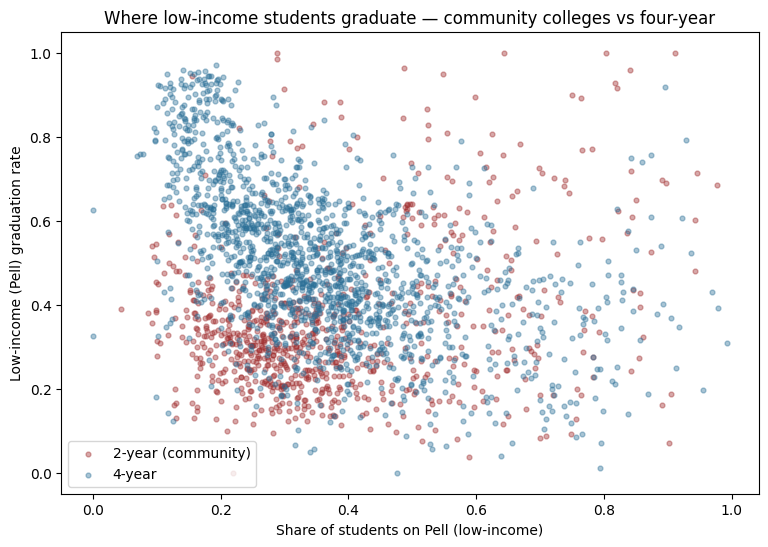

In [7]:
import matplotlib.pyplot as plt

colors = {"2-year (community)": "#9e2a2b", "4-year": "#2a6f97"}
plt.figure(figsize=(9, 6))
for lvl, c in colors.items():
    s = clean[clean["level"] == lvl]
    plt.scatter(s["pell_share"], s["grad_low_income"], s=12, alpha=0.4, color=c, label=lvl)

plt.xlabel("Share of students on Pell (low-income)")
plt.ylabel("Low-income (Pell) graduation rate")
plt.title("Where low-income students graduate — community colleges vs four-year")
plt.legend()
plt.show()

## 8 · Export — hand the data to your explorer tool

**What this does:** writes the cleaned data to a `schools.json` file and downloads it, so you can drop it into the College Finder explorer (replacing the placeholder data).

🔑 **Key idea:** `orient="records"` makes a **list of school objects** — the exact shape the tool reads. Open-admission schools get `admission_rate = 1.0` ("admits ~everyone") so the tool's reachability filter works for them.

In [8]:
import json

export = clean[[
    "name", "state", "sector", "level", "size", "admission_rate",
    "pell_share", "net_price_low_income", "grad_all", "grad_low_income", "equity_gap"
]].copy()

# open-admission schools (mostly community colleges) report no admission rate -> treat as ~100% admitted
export["admission_rate"] = export["admission_rate"].fillna(1.0)

# round so the JSON is clean (no 0.0031000000047)
for col in ["admission_rate", "pell_share", "grad_all", "grad_low_income", "equity_gap"]:
    export[col] = export[col].round(4)
export["net_price_low_income"] = export["net_price_low_income"].round(0)

# keep rows that have the pieces the tool displays
export = export.dropna(subset=["net_price_low_income", "pell_share"])
export.to_json("schools.json", orient="records")
print(f"Wrote schools.json with {len(export)} schools.")

from google.colab import files
files.download("schools.json")

Wrote schools.json with 2423 schools.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What's next

- **Wire `schools.json` into the explorer** — replace the placeholder rows, and update the tool to handle community colleges (open-admission display, a 2-year/4-year filter).
- **The writeup** — tell the story for a hiring manager: the equity gap, the community-college comparison, the suppression caveat.

*Set aside for now:* the predictor model (the regression). Mixing 2-year and 4-year schools muddies it, so when you return to modeling, do it **within a single level**. Your earlier notebook still has that code.

💡 **To practice:** clear all outputs (Edit → Clear all outputs) and predict each cell's result before running it. That's the fastest way from "I get it" to "I could do it."